# Inverted rotary-bar pendulum PID control — explained version

이 노트북은 `02_inverted_pid_control.ipynb`의 별도 설명 버전입니다.
원본의 모델과 시뮬레이션 구조는 유지하면서, PID 폐루프 특성방정식이 어떻게 만들어지는지와 gain 계산의 의미를 단계별로 설명합니다.

좌표계는 **upright(완전히 위로 선 상태)를 \(\theta=0\)** 로 정의합니다.

\[
\ddot\theta-a\theta=bu,\qquad u=\ddot\phi
\]

\[
a=\frac{3g}{2l},\qquad b=\frac{3r}{2l}
\]

\[
P_i(s)=\frac{\Theta(s)}{U(s)}=\frac{b}{s^2-a}
\]


## 4. PID 출력의 물리적 의미: \(u=\ddot\phi\)

이 모델에서 PID 출력 \(u\)는 rotary arm의 **각가속도 명령**입니다.

\[
u=K_pe+K_i\int e\,dt+K_d\dot e,\qquad u=\ddot\phi
\]

upright reference가 \(\theta_{ref}=0\)이므로

\[
e=-\theta.
\]

즉 `pendulum angle -> error -> PID -> rotary-arm acceleration -> pendulum dynamics` 구조입니다.


## 5. Closed-loop characteristic equation 유도

Plant와 controller는

\[
P(s)=\frac{b}{s^2-a},\qquad
C(s)=K_p+\frac{K_i}{s}+K_ds
\]

입니다.

\(E=-\Theta\), \(U=CE=-C\Theta\), \(\Theta=PU\)를 결합하면

\[
1+\frac{bC(s)}{s^2-a}=0
\]

이므로

\[
s^2-a+bC(s)=0.
\]

PID를 대입하고 전체에 \(s\)를 곱하면

\[
\boxed{s^3+bK_ds^2+(bK_p-a)s+bK_i=0}
\]

이 됩니다.


## 6. 왜 2차 plant가 3차가 되는가

원래 plant는 \(s^2-a\)를 분모로 가지므로 2차입니다.
PID의 integral term \(K_i/s\)가 원점 pole 하나를 추가하므로 closed-loop characteristic polynomial은 3차가 됩니다.


## 7. 원하는 pole을 \(-4,-5,-6\)으로 선택

\[
(s+4)(s+5)(s+6)=s^3+15s^2+74s+120
\]

입니다. 세 pole이 모두 왼쪽 반평면에 있으므로 목표 closed-loop는 안정합니다.


## 8. 계수 비교로 PID gain 계산

실제 characteristic polynomial

\[
s^3+bK_ds^2+(bK_p-a)s+bK_i
\]

와 목표 polynomial

\[
s^3+15s^2+74s+120
\]

의 계수를 비교하면

\[
bK_d=15,\qquad bK_p-a=74,\qquad bK_i=120
\]

을 얻습니다.


In [1]:
from pathlib import Path
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

g = 9.81
l = 0.235
r = 0.14

a = 3*g/(2*l)
b = 3*r/(2*l)

desired_poles = np.array([-4.0, -5.0, -6.0])
poly = np.poly(desired_poles)

Kd = poly[1] / b
Kp = (poly[2] + a) / b
Ki = poly[3] / b

print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"Plant: Theta/U = {b:.6f} / (s^2 - {a:.6f})")
print(f"Kp = {Kp:.6f}")
print(f"Ki = {Ki:.6f}")
print(f"Kd = {Kd:.6f}")


a = 62.617021
b = 0.893617
Plant: Theta/U = 0.893617 / (s^2 - 62.617021)
Kp = 152.880952
Ki = 134.285714
Kd = 16.785714


## 9. \(K_d\) 계산

\[
K_d=\frac{15}{b}\approx16.786
\]

입니다. Derivative 항은 빠른 각도 변화에 반응하여 damping을 추가합니다.


## 10. \(K_p\) 계산

\[
K_p=\frac{74+a}{b}\approx152.881
\]

입니다. 이 proportional gain은 upright에서 중력이 만드는 불안정 효과를 제어기가 이길 수 있도록 충분히 커야 합니다.


## 11. \(K_i\) 계산

\[
K_i=\frac{120}{b}\approx134.286
\]

입니다. Integral 항은 bias나 steady-state offset을 누적해 보정합니다. 실제 하드웨어에서는 saturation과 결합될 때 windup에 주의해야 합니다.


## 12. 왜 \(K_p>a/b=g/r\)가 필요한가

Characteristic polynomial의 \(s\) 계수는 \(bK_p-a\)입니다.
적어도 양수가 되려면

\[
bK_p-a>0
\]

즉

\[
K_p>\frac{a}{b}.
\]

그런데

\[
a=\frac{3g}{2l},\qquad b=\frac{3r}{2l}
\]

이므로

\[
\frac{a}{b}=\frac{g}{r}.
\]

따라서

\[
\boxed{K_p>\frac{g}{r}\approx70.07}
\]

입니다.


## 13. \(K_p>a/b\)의 물리적 의미

제어가 없으면

\[
\ddot\theta=a\theta
\]

이므로 \(\theta>0\)일 때 \(\ddot\theta>0\)가 되어 더 넘어지는 방향으로 가속합니다.

P-control만 보면

\[
u=-K_p\theta
\]

이므로

\[
\ddot\theta=(a-bK_p)\theta.
\]

따라서 중력의 불안정 효과보다 feedback 효과가 강하려면

\[
bK_p>a
\]

가 필요합니다.

즉 이 조건은 단순한 대수 조건이 아니라 **rotary arm acceleration feedback이 중력에 의한 upright 불안정성을 이겨야 한다**는 물리 조건입니다.


## 15. 실제 stepper 때문에 acceleration saturation을 넣는 이유

이론 PID는 큰 오차에서 매우 큰 \(u\)를 만들 수 있지만 실제 stepper는 토크와 속도 한계가 있습니다.

이 예에서는

\[
|u|\le30\;\mathrm{rad/s^2}
\]

로 제한합니다.

```python
u_unsat = Kp*e + Ki*integ_e + Kd*e_dot
u = np.clip(u_unsat, -u_max, u_max)
```

Pole placement는 선형 시스템을 가정하지만 saturation은 nonlinear 요소입니다. 따라서 saturation에 걸리는 동안은 정확한 \(-4,-5,-6\) pole 응답과 달라집니다.


## 16. 이 모델이 실제 stepper에서 생략한 actuator dynamics

이 모델은 PID가 \(u=\ddot\phi\)를 명령하면 실제 arm acceleration이 즉시 정확히 \(u\)가 된다고 가정합니다.

하지만 실제 시스템은

```text
Jupyter controller
    ↓
acceleration command
    ↓
MCU에서 velocity 적분
    ↓
STEP pulse frequency
    ↓
L6474 + stepper
    ↓
actual rotor acceleration
```

이므로

\[
u_{PID}\neq\ddot\phi_{actual}
\]

일 수 있습니다.

torque-speed limit, friction, resonance, missed step, supply voltage, load inertia 등이 원인입니다.


## 17. 전체 구조 요약

```text
theta_ref = 0
      ↓
e = -theta
      ↓
PID
      ↓
u = phi_ddot
      ↓
rotary arm acceleration
      ↓
pendulum plant
      ↓
theta
```

핵심 운동방정식은

\[
\ddot\theta=a\theta+bu
\]

이고 PID는

\[
u=-K_p\theta-K_i\int\theta\,dt-K_d\dot\theta
\]

로 작동합니다.

즉 PID가 중력이 만드는 불안정 항 \( +a\theta \)를 반대 방향의 rotary-arm acceleration으로 제압합니다.


# Simulation

초기조건은 upright에서 \(5^\circ\) 기울어진 상태입니다.

- \(\theta(0)=5^\circ\)
- \(\dot\theta(0)=0\)
- \(\theta_{ref}=0\)
- \(|u|\le30\,\mathrm{rad/s^2}\)

또한 \(u=\ddot\phi\)를 적분하여 rotary-arm velocity와 position도 함께 계산합니다.


In [2]:
theta0 = np.deg2rad(5.0)
u_max = 30.0
t_end = 5.0

def rhs(t, x):
    theta, theta_dot, integ_e, phi, phi_dot = x
    e = -theta
    e_dot = -theta_dot

    u_unsat = Kp*e + Ki*integ_e + Kd*e_dot
    u = np.clip(u_unsat, -u_max, u_max)

    theta_ddot = a*theta + b*u
    return [theta_dot, theta_ddot, e, phi_dot, u]

t_eval = np.linspace(0, t_end, 5001)

sol = solve_ivp(
    rhs,
    (0, t_end),
    [theta0, 0, 0, 0, 0],
    t_eval=t_eval,
    max_step=0.001,
    rtol=1e-9,
    atol=1e-11,
)

t = sol.t
theta, theta_dot, integ_e, phi, phi_dot = sol.y

e = -theta
e_dot = -theta_dot
u_unsat = Kp*e + Ki*integ_e + Kd*e_dot
u = np.clip(u_unsat, -u_max, u_max)

band = np.deg2rad(0.1)
settling_time = np.nan
for i in range(len(t)):
    if np.all(np.abs(theta[i:]) <= band):
        settling_time = t[i]
        break

print(f"peak |u| = {np.max(np.abs(u)):.4f} rad/s^2")
print(f"min theta = {np.rad2deg(np.min(theta)):.4f} deg")
print(f"final theta = {np.rad2deg(theta[-1]):.6f} deg")
print(f"settling time into +/-0.1 deg band = {settling_time:.4f} s")
print(f"final phi_dot = {phi_dot[-1]:.6f} rad/s")
print(f"final phi = {np.rad2deg(phi[-1]):.3f} deg")


peak |u| = 13.3414 rad/s^2
min theta = -1.2219 deg
final theta = -0.000000 deg
settling time into +/-0.1 deg band = 1.6230 s
final phi_dot = -0.000000 rad/s
final phi = -49.390 deg


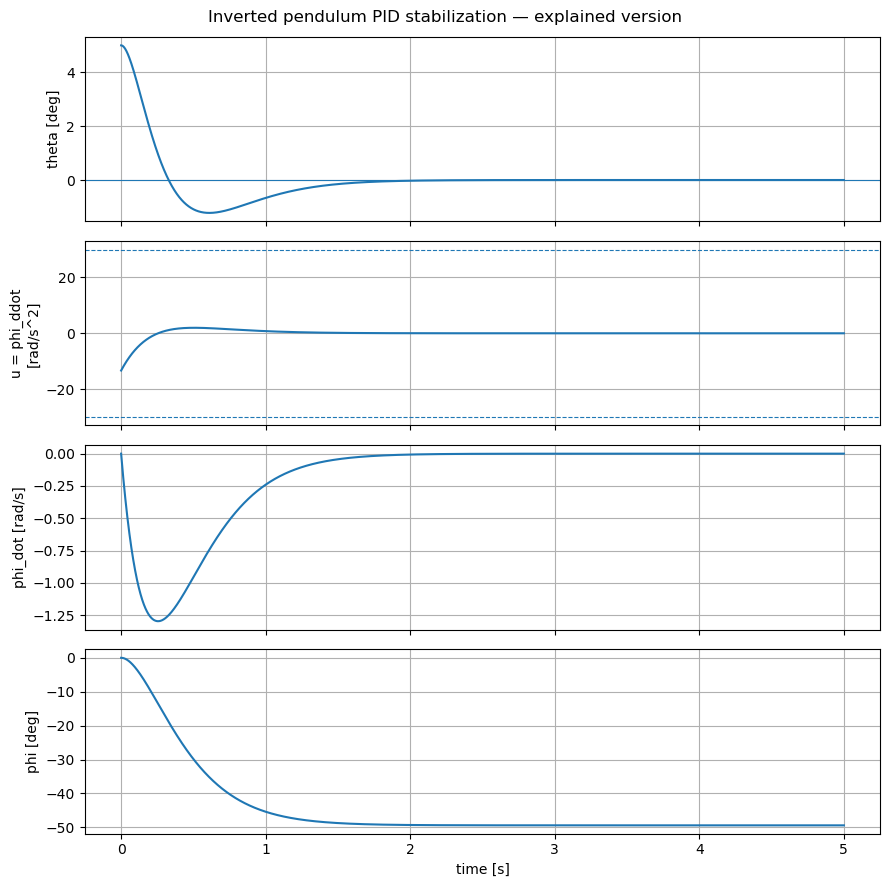

saved: figures\inverted_pid_response_explained.svg


In [3]:
fig, axes = plt.subplots(4, 1, figsize=(9, 9), sharex=True)

axes[0].plot(t, np.rad2deg(theta))
axes[0].axhline(0, linewidth=0.8)
axes[0].set_ylabel("theta [deg]")
axes[0].grid(True)

axes[1].plot(t, u)
axes[1].axhline(u_max, linestyle="--", linewidth=0.8)
axes[1].axhline(-u_max, linestyle="--", linewidth=0.8)
axes[1].set_ylabel("u = phi_ddot\n[rad/s^2]")
axes[1].grid(True)

axes[2].plot(t, phi_dot)
axes[2].set_ylabel("phi_dot [rad/s]")
axes[2].grid(True)

axes[3].plot(t, np.rad2deg(phi))
axes[3].set_ylabel("phi [deg]")
axes[3].set_xlabel("time [s]")
axes[3].grid(True)

fig.suptitle("Inverted pendulum PID stabilization — explained version")
fig.tight_layout()

out_dir = Path("figures")
out_dir.mkdir(exist_ok=True)
fig_path = out_dir / "inverted_pid_response_explained.svg"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"saved: {fig_path}")
